## This notebook trains the classical model on the MRPC dataset. The accuracy will be measured and stored for final performance comparisons

In [22]:
#Importing required packages
import os
import sys
import time
from pathlib import Path
from datetime import date

import joblib
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

sys.path.append(os.path.abspath(".."))

from src.classical_models import (
    combine_sentences,
    create_tfidf_vectorizer,
    vectorize_data,
    train_logistic_regression,
    predict,
    save_classical_model
)

from src.evaluate import (
    evaluate_classifier,
    compute_confusion_matrix
)

from src.utils import log_experiment

# 1. MRPC

In [2]:
#Load the processed datasets
train = pd.read_csv(
    "../datasets/processed/classical/mrpc_train.csv"
)

validation = pd.read_csv(
    "../datasets/processed/classical/mrpc_validation.csv"
)

test = pd.read_csv(
    "../datasets/processed/classical/mrpc_test.csv"
)

In [23]:
#Overview
print("Training:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

display(train.head())

print("\nMissing Values")
display(train.isnull().sum())

print("\nLabel Distribution")
display(train["label"].value_counts())

Training: (3668, 4)
Validation: (408, 4)
Test: (1725, 4)


,sentence1,sentence2,label,idx
0,"amrozi accused his brother , whom he called "" ...","referring to him as only "" the witness "" , amr...",1,0
1,yucaipa owned dominick 's before selling the c...,yucaipa bought dominick 's in 1995 for $ 693 m...,0,1
2,they had published an advertisement on the int...,"on june 10 , the ship 's owners had published ...",1,2
3,"around 0335 gmt , tab shares were up 19 cents ...","tab shares jumped 20 cents , or 4.6 % , to set...",0,3
4,"the stock rose $ 2.11 , or about 11 percent , ...",pg & e corp. shares jumped $ 1.63 or 8 percent...,1,4



Missing Values


sentence1    0
sentence2    0
label        0
idx          0
dtype: int64


Label Distribution


label
1    2474
0    1194
Name: count, dtype: int64

In [3]:
#Combine Sentence Pairs
def combine_sentences(df):
    return (
        df["sentence1"]
        + " [SEP] "
        + df["sentence2"]
    )

In [4]:
X_train = combine_sentences(train)
X_validation = combine_sentences(validation)
X_test = combine_sentences(test)

y_train = train["label"]
y_validation = validation["label"]
y_test = test["label"]

In [24]:
#Define the TF-IDF Vectorizer
vectorizer = create_tfidf_vectorizer()

In [25]:
(
    X_train_vector,
    X_validation_vector,
    X_test_vector
) = vectorize_data(
    vectorizer,
    X_train,
    X_validation,
    X_test
)

In [26]:
#Training a Logistic Regression model
start_time = time.perf_counter()

model = train_logistic_regression(
    X_train_vector,
    y_train
)

end_time = time.perf_counter()

training_time = end_time - start_time

print(f"Training Time: {training_time:.4f} seconds")

Training Time: 0.0366 seconds


In [27]:
#Predictions
start_time = time.perf_counter()

predictions, probabilities = predict(
    model,
    X_validation_vector
)

end_time = time.perf_counter()

inference_time = end_time - start_time

print(f"Inference Time: {inference_time:.4f} seconds")

Inference Time: 0.0010 seconds


In [28]:
#Evaluation
metrics = evaluate_classifier(
    y_validation,
    predictions,
    probabilities
)

for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

Accuracy: 0.7279
Precision: 0.7234
Recall: 0.9749
F1: 0.8305
ROC-AUC: 0.6759


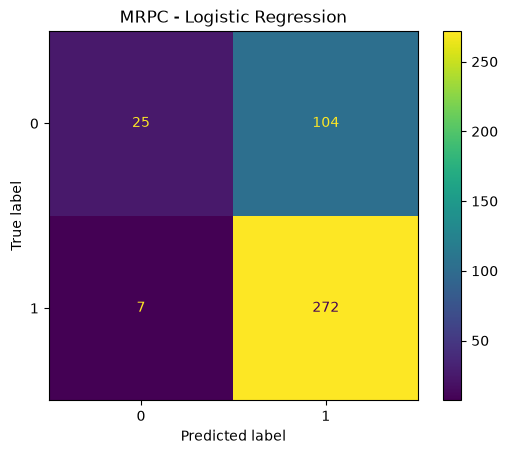

In [29]:
cm = compute_confusion_matrix(
    y_validation,
    predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("MRPC - Logistic Regression")

plt.savefig(
    "../results/plots/mrpc_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

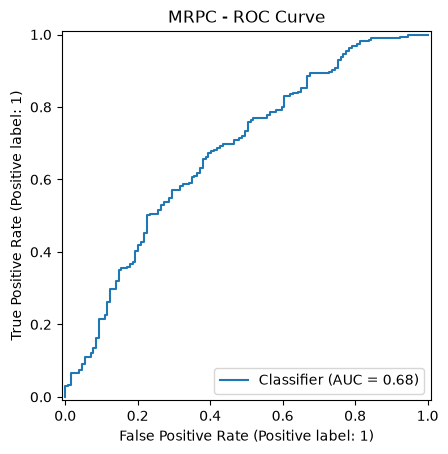

In [30]:
RocCurveDisplay.from_predictions(
    y_validation,
    probabilities
)

plt.title("MRPC - ROC Curve")

plt.savefig(
    "../results/plots/mrpc_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [31]:
#Saving the results
predictions_df = validation.copy()

predictions_df["prediction"] = predictions
predictions_df["probability"] = probabilities

predictions_df.to_csv(
    "../results/predictions/mrpc_predictions.csv",
    index=False
)

predictions_df.head()

,sentence1,sentence2,label,idx,prediction,probability
0,he said the foodservice pie business doesn 't ...,""" the foodservice pie business does not fit ou...",1,9,1,0.852123
1,magnarelli said racicot hated the iraqi regime...,"his wife said he was "" 100 percent behind geor...",0,18,1,0.649710
2,"the dollar was at 116.92 yen against the yen ,...","the dollar was at 116.78 yen jpy = , virtually...",0,25,0,0.496229
3,the afl-cio is waiting until october to decide...,the afl-cio announced wednesday that it will d...,1,32,1,0.688216
4,no dates have been set for the civil or the cr...,no dates have been set for the criminal or civ...,0,33,1,0.628857


In [32]:
#Saving the predictions
predictions = validation.copy()
predictions["prediction"] = validation_predictions
predictions["probability"] = validation_probabilities

predictions.to_csv(
    "../results/predictions/mrpc_predictions.csv",
    index=False
)

metrics_df = pd.DataFrame([metrics])

metrics_df.to_csv(
    "../results/metrics/mrpc_logreg_metrics.csv",
    index=False
)

metrics_df

,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.727941,0.723404,0.97491,0.830534,0.675863


In [33]:
#Saving the model
Path("../models/classical").mkdir(
    parents=True,
    exist_ok=True
)

save_classical_model(
    model,
    vectorizer,
    "../models/classical/logistic_regression.pkl",
    "../models/classical/tfidf_vectorizer.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [34]:
#Error Analysis
errors = predictions_df[
    predictions_df["label"] != predictions_df["prediction"]
]

print(f"Incorrect Predictions: {len(errors)}")

errors.head(20)

Incorrect Predictions: 111


,sentence1,sentence2,label,idx,prediction,probability
1,magnarelli said racicot hated the iraqi regime...,"his wife said he was "" 100 percent behind geor...",0,18,1,0.649710
4,no dates have been set for the civil or the cr...,no dates have been set for the criminal or civ...,0,33,1,0.628857
6,while dioxin levels in the environment were up...,the institute said dioxin levels in the enviro...,0,54,1,0.701684
11,""" sanitation is poor ... there could be typhoi...",""" sanitation is poor , drinking water is gener...",0,83,1,0.699066
19,the pound also made progress against the dolla...,the british pound flexed its muscle against th...,0,175,1,0.514979
22,"the driver , eugene rogers , helped to remove ...","at the accident scene , the driver was "" cover...",0,222,1,0.683913
26,cooley said he expects muhammad will similarly...,lee boyd malvo will be called as a witness wed...,0,284,1,0.699723
30,"with these assets , funny cide has a solid cha...",funny cide is looking to become horse racing '...,0,334,1,0.749794
35,"bush wanted "" to see an aircraft landing the s...","on tuesday , before byrd 's speech , fleischer...",0,374,1,0.828424
36,"on monday the palestinian prime minister , mah...",palestinian prime minister mahmoud abbas must ...,0,375,1,0.715886


In [35]:
#Logging the output
experiment = {
    "Experiment ID": "EXP-001",
    "Date": date.today().isoformat(),
    "Phase": "Baseline",
    "Model": "Logistic Regression",
    "Dataset": "MRPC",
    "Train Split": len(train),
    "Validation Split": len(validation),
    "Test Split": len(test),
    "Batch Size": "N/A",
    "Learning Rate": "N/A",
    "Epochs": "N/A",
    "Accuracy": metrics["Accuracy"],
    "Precision": metrics["Precision"],
    "Recall": metrics["Recall"],
    "F1": metrics["F1"],
    "ROC-AUC": metrics["ROC-AUC"],
    "BLEU": "N/A",
    "ROUGE": "N/A",
    "BERTScore": "N/A",
    "Train Time": training_time,
    "Inference Time": inference_time,
    "Notes": "TF-IDF (1,2)-gram baseline",
    "Status": "Completed"
}

log_experiment(
    "../logs/experiments.xlsx",
    experiment
)

print("Experiment logged successfully.")

Experiment logged successfully.


In [36]:
#Summary
print("=" * 60)
print("MRPC BASELINE COMPLETE")
print("=" * 60)

print(f"Accuracy      : {metrics['Accuracy']:.4f}")
print(f"Precision     : {metrics['Precision']:.4f}")
print(f"Recall        : {metrics['Recall']:.4f}")
print(f"F1 Score      : {metrics['F1']:.4f}")
print(f"ROC-AUC       : {metrics['ROC-AUC']:.4f}")
print(f"Training Time : {training_time:.4f} sec")
print(f"Inference Time: {inference_time:.4f} sec")

print("\nArtifacts Generated:")
print("- Model")
print("- Vectorizer")
print("- Metrics CSV")
print("- Predictions CSV")
print("- Confusion Matrix")
print("- ROC Curve")
print("- Experiment Log")

MRPC BASELINE COMPLETE
Accuracy      : 0.7279
Precision     : 0.7234
Recall        : 0.9749
F1 Score      : 0.8305
ROC-AUC       : 0.6759
Training Time : 0.0366 sec
Inference Time: 0.0010 sec

Artifacts Generated:
- Model
- Vectorizer
- Metrics CSV
- Predictions CSV
- Confusion Matrix
- ROC Curve
- Experiment Log
